In [2]:
import pandas as pd
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")

In [21]:
import torch
buffer = torch.load("/data1/xw3763/project/gflow/ChemGFN/data/24_points/buffer_24_non_zero.pt")

In [23]:
decoded_ref = tokenizer.batch_decode(buffer, skip_special_tokens=True)

In [ ]:
# calculate the tokens distribution at each position
tokens_distribution_each_pos = {}
for t in range(len(decoded_ref[0])):
    tokens_distribution = {}
    for i in range(len(decoded_ref)):
        tokens_distribution[decoded_ref[i][t]] = tokens_distribution.get(decoded_ref[i][t], 0) + 1
    tokens_distribution_each_pos[t] = tokens_distribution

{0: {'1': 161,
  '2': 225,
  '3': 312,
  '4': 335,
  '5': 237,
  '6': 356,
  '7': 225,
  '8': 365,
  '9': 304},
 1: {'-': 121, '*': 1197, '/': 248, '+': 954},
 2: {'1': 238,
  '2': 286,
  '3': 343,
  '4': 327,
  '5': 255,
  '6': 304,
  '7': 222,
  '8': 290,
  '9': 255},
 3: {'+': 1097, '*': 856, '/': 264, '-': 303},
 4: {'3': 355,
  '4': 312,
  '6': 293,
  '8': 286,
  '2': 322,
  '5': 225,
  '7': 209,
  '9': 249,
  '1': 269},
 5: {'*': 926, '+': 954, '-': 384, '/': 256},
 6: {'8': 318,
  '6': 323,
  '4': 307,
  '3': 343,
  '7': 206,
  '5': 205,
  '2': 283,
  '9': 264,
  '1': 271}}

In [16]:
df = pd.read_csv("/data1/xw3763/project/gflow/ChemGFN/logs/train/debug_expr24_unispace_SubTB_diff_mem_phi_1_no_backoff/train/runs/2025-12-22_06-21-00/validation_samples/samples_val_probes_16472.csv")

In [18]:
decoded_sentences = df["Sampled sentence"]

In [27]:
tokens_distribution_each_pos_sampled = {}
for t in range(len(decoded_ref[0])):
    tokens_distribution = {}
    for i in range(len(decoded_sentences)):
        tokens_distribution[decoded_sentences[i][t]] = tokens_distribution.get(decoded_sentences[i][t], 0) + 1
    tokens_distribution_each_pos_sampled[t] = tokens_distribution

<BarContainer object of 8 artists>

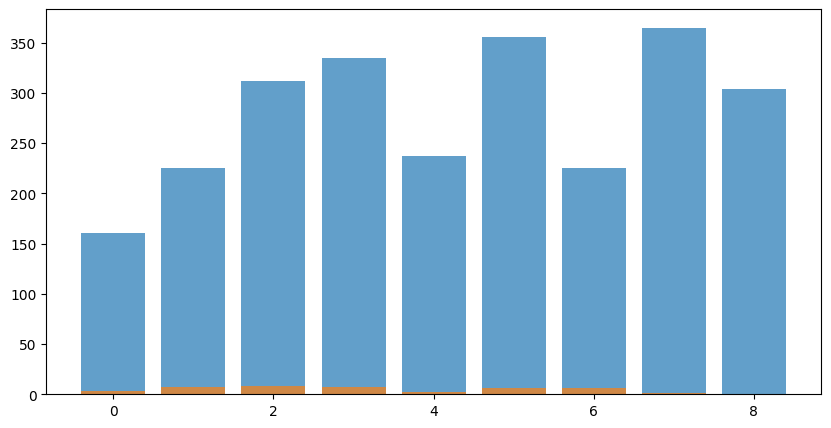

In [32]:
# draw distribution according to the key name
import matplotlib.pyplot as plt

ref_freq_list = [x for x in tokens_distribution_each_pos[0].values()]
sampled_freq_list = [x if x is not None else 0 for x in tokens_distribution_each_pos_sampled[0].values() ]

plt.figure(figsize=(10, 5))
plt.bar(range(len(ref_freq_list)), ref_freq_list, label='Reference Distribution', alpha=0.7)
plt.bar(range(len(sampled_freq_list)), sampled_freq_list, label='Sampled Distribution', alpha=0.7)



In [29]:
# calculate the KL divergence between the two distributions
kl_divergence = {}
for t in range(len(decoded_ref[0])):
    kl_divergence[t] = kl_divergence.get(t, 0) + kl_divergence(tokens_distribution_each_pos[t], tokens_distribution_each_pos_sampled[t])
kl_divergence

TypeError: 'dict' object is not callable